In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Загружаем данные
blocks = gpd.read_parquet("../data/traning_data/prepared_blocks_spb.parquet").copy()

blocks.head()


,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,mxi,l,osr,share_living,share_non_living,morphotype,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,0.000000,1.000000,1985.451134,0.000000,1.000000,low-rise non-residential,113.847998,942.386203,18.676889,6.849476
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,0.687302,1.043202,14.637095,0.716995,0.326207,individual residential,145.884534,1952.414484,19.040968,7.577334
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,0.693362,1.038117,27.815100,0.719791,0.318326,individual residential,148.543184,1507.223306,19.061421,7.318688
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,0.667715,2.332762,5.008184,1.557620,0.775142,low-rise model,132.691062,2197.747147,19.737919,7.695643
5,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,0.000000,4.000000,0.749690,0.000000,4.000000,mid-rise non-residential,99.160727,8603.688296,17.843517,9.060062


count    8.728000e+03
mean     5.013825e+08
std      1.026024e+09
min      8.695103e+01
25%      5.457330e+07
50%      1.586168e+08
75%      4.898793e+08
max      2.353281e+10
Name: land_value, dtype: float64


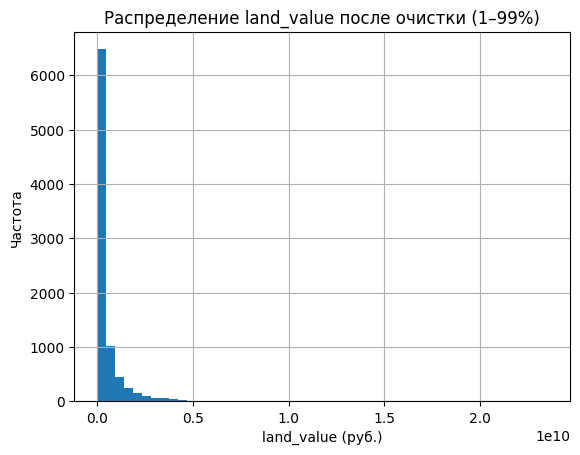

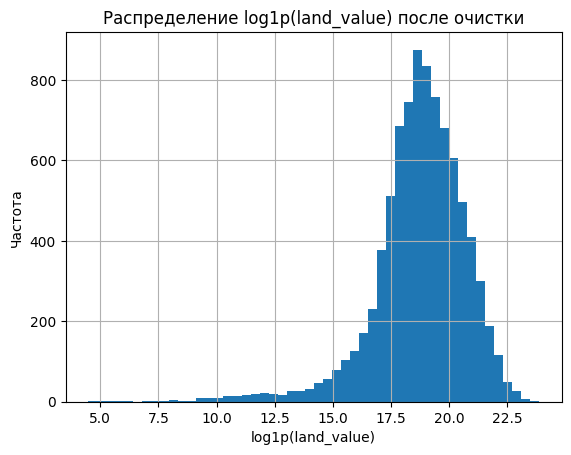

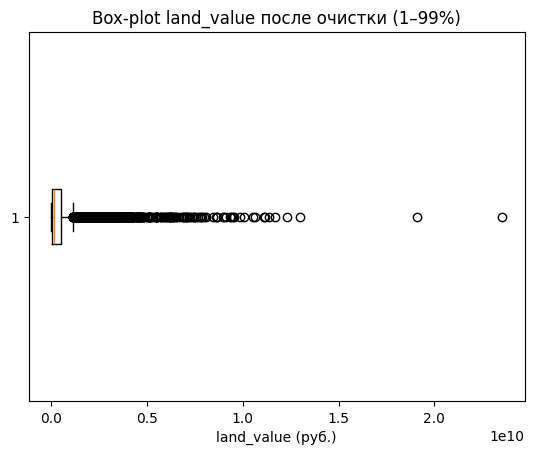

In [12]:
import numpy as np

blocks = blocks.copy()

# Базовая валидность
blocks = blocks[blocks["site_area"] > 1]
blocks = blocks[blocks["land_value"] > 1]

# Чистка NaN/inf
blocks = blocks.replace([np.inf, -np.inf], np.nan)
blocks = blocks.dropna(subset=["land_value"])

# Trim по land_value (1-99 перцентили)
p1 = blocks["land_value"].quantile(0.01)
p99 = blocks["land_value"].quantile(0.99)

# blocks_clean = blocks[
#     (blocks["land_value"] >= p1) &
#     (blocks["land_value"] <= p99)
# ].copy()

blocks_clean = blocks.copy()
print(blocks_clean["land_value"].describe())

# 5) Лог-цель для обучения (рекомендуется при heavy-tail)
blocks_clean["log_land_value"] = np.log1p(blocks_clean["land_value"])

# 6) Гистограмма raw после очистки
plt.figure()
blocks_clean["land_value"].hist(bins=50)
plt.xlabel("land_value (руб.)")
plt.ylabel("Частота")
plt.title("Распределение land_value после очистки (1–99%)")
plt.show()

# 7) Гистограмма log1p (обычно гораздо информативнее)
plt.figure()
blocks_clean["log_land_value"].hist(bins=50)
plt.xlabel("log1p(land_value)")
plt.ylabel("Частота")
plt.title("Распределение log1p(land_value) после очистки")
plt.show()

# 8) Box-plot raw
plt.figure()
plt.boxplot(blocks_clean["land_value"], vert=False)
plt.xlabel("land_value (руб.)")
plt.title("Box-plot land_value после очистки (1–99%)")
plt.show()

# KMeans

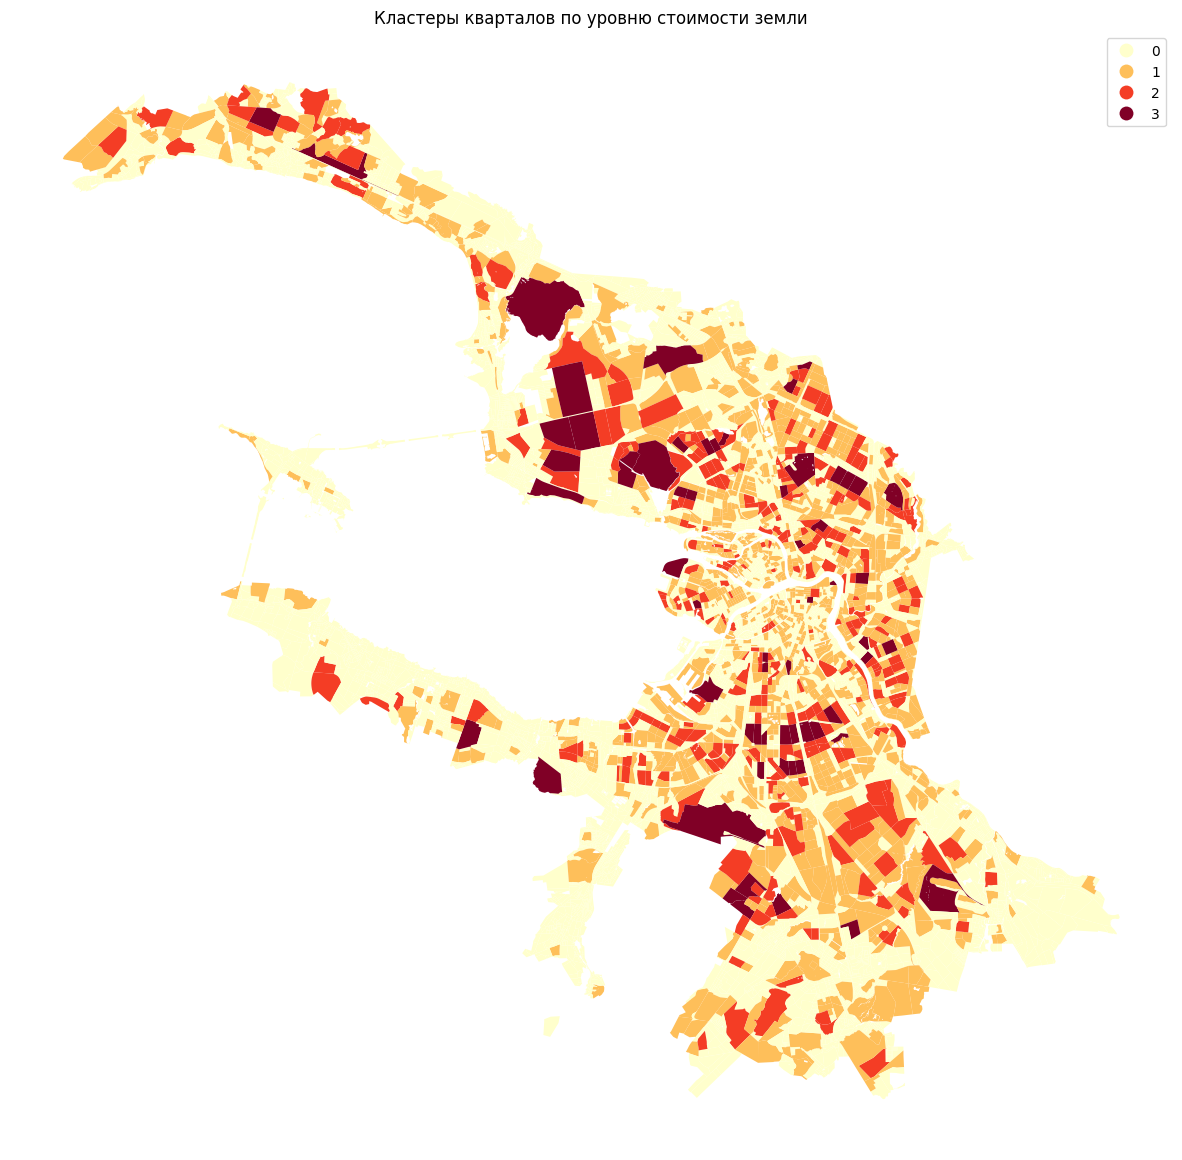

land_value_class
0    7164
1    1189
2     313
3      62
Name: count, dtype: Int64


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans

# # 1. Берём только валидные значения
# mask = blocks_clean["land_value"].notna()
# X = blocks_clean.loc[mask, ["land_value"]]

# # 2. Обучаем KMeans
# kmeans = KMeans(n_clusters=4, random_state=0, n_init=20)
# raw_clusters = kmeans.fit_predict(X)

# # 3. Сортируем кластеры по центрам (по стоимости)
# centers = kmeans.cluster_centers_.ravel()
# order = np.argsort(centers)

# # создаём отображение старого номера в упорядоченный
# cluster_mapping = {old: new for new, old in enumerate(order)}

# ordered_clusters = np.vectorize(cluster_mapping.get)(raw_clusters)

# # 4. Записываем обратно
# blocks_clean.loc[mask, "land_value_class"] = ordered_clusters.astype(int)

# # (опционально) сохраняем тип с поддержкой NaN
# blocks_clean["land_value_class"] = blocks_clean["land_value_class"].astype("Int64")

# # 5. Визуализация
# fig, ax = plt.subplots(figsize=(15, 15))

# blocks_clean.plot(
#     column="land_value_class",
#     categorical=True,
#     cmap="YlOrRd",
#     legend=True,
#     ax=ax
# )

# ax.set_axis_off()
# ax.set_title("Кластеры кварталов по уровню стоимости земли")

# plt.show()

# blocks_class = blocks_clean.copy()
# print(blocks_class["land_value_class"].value_counts(dropna=False))

# Квантили

land_value_class
1    2182
2    2182
0    2182
3    2182
Name: count, dtype: Int64


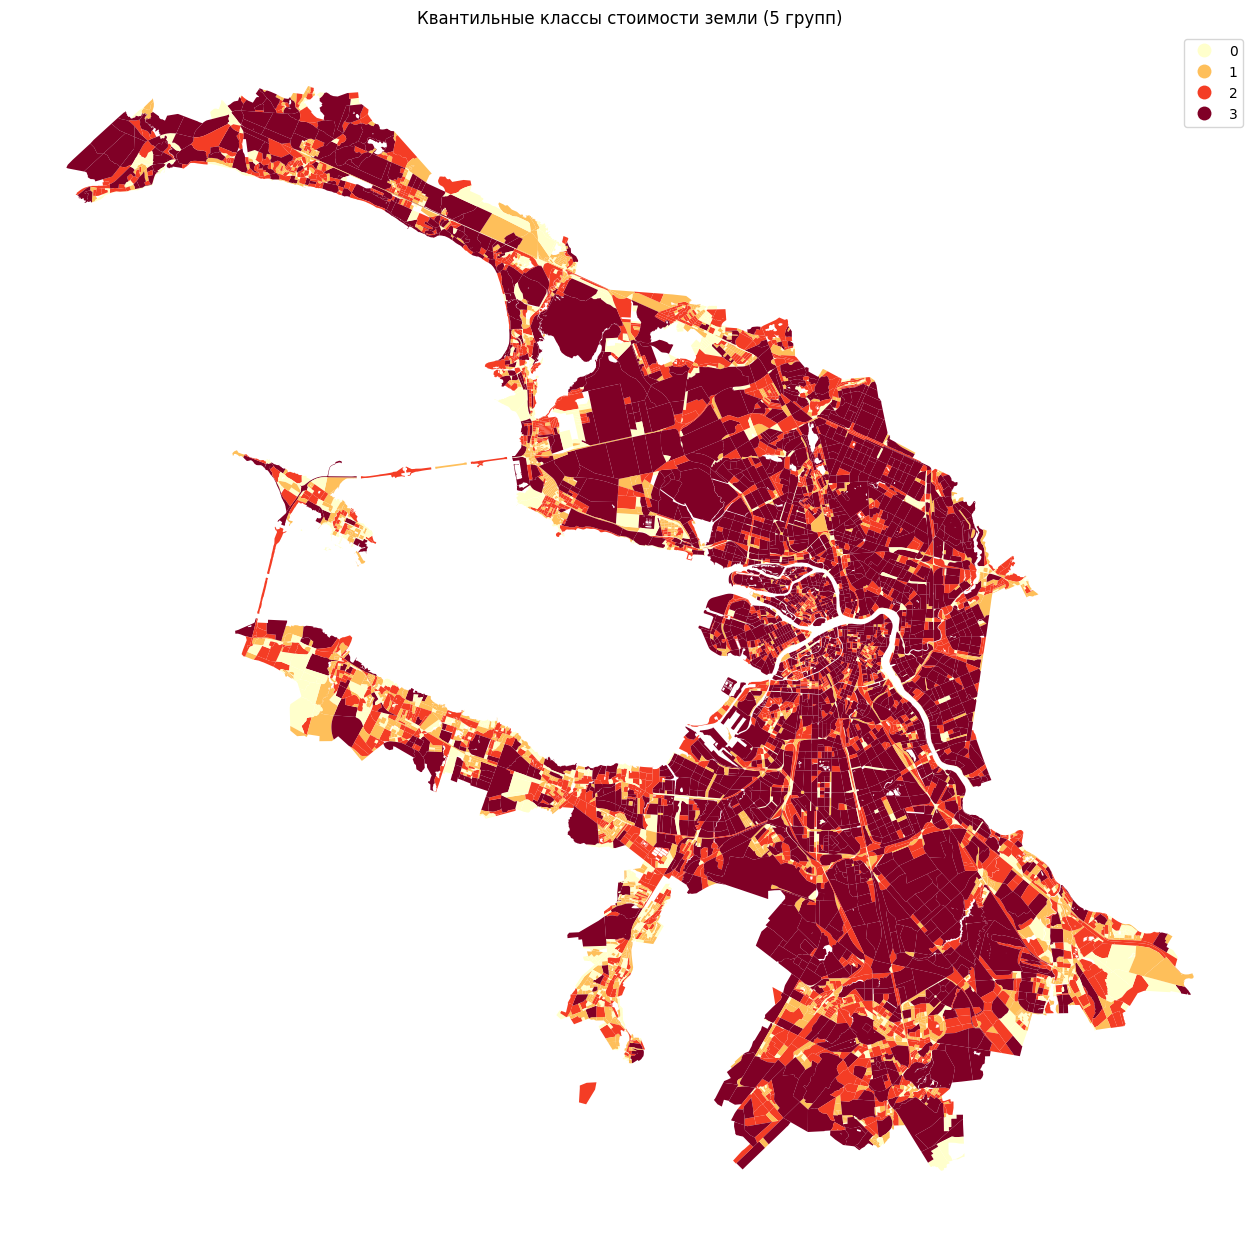

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

blocks_class = blocks_clean.copy()

mask = blocks_class["log_land_value"].notna()

blocks_class.loc[mask, "land_value_class"] = pd.qcut(
    blocks_class.loc[mask, "log_land_value"],
    q=4,
    labels=False,
    duplicates="drop"
).astype(int)

# чтобы сохранить NaN корректно
blocks_class["land_value_class"] = blocks_class["land_value_class"].astype("Int64")
print(blocks_class["land_value_class"].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(16, 16))

blocks_class.plot(
    column="land_value_class",
    cmap="YlOrRd",      # можно "plasma", "magma", "RdYlGn"
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title("Квантильные классы стоимости земли (5 групп)")
ax.set_axis_off()

plt.show()

# **CatBoostClassifier**

In [14]:
import pandas as pd

# 1. Отбираем числовые столбцы и фильтруем
num = blocks_class.select_dtypes(include=['number'])
num = num[num['land_value'] > 1]

# 2. Считаем count + статистики
agg_stats = num.agg(['count', 'min', 'max', 'mean', 'median', 'std']).T

# 3. Переименовываем столбцы
agg_stats.index.name = 'Variable'
agg_stats = agg_stats.rename(columns={
    'count':  'Count',
    'min':    'Min',
    'max':    'Max',
    'mean':   'Mean',
    'median': 'Median',
    'std':    'SD'
})

# 4. Приводим Count к int
agg_stats['Count'] = agg_stats['Count'].astype(int)

# 5. Округляем остальные метрики
for col in ['Min','Max','Mean','Median','SD']:
    agg_stats[col] = agg_stats[col].round(2)

# 6. Настраиваем глобальный формат для float
pd.options.display.float_format = '{:,.2f}'.format

# 7. Показываем результат
agg_stats

,Count,Min,Max,Mean,Median,SD
Variable,,,,,,
residential,8728,0.00,1.00,0.51,0.68,0.43
business,8728,0.00,1.00,0.03,0.00,0.15
recreation,8728,0.00,1.00,0.19,0.00,0.33
industrial,8728,0.00,1.00,0.05,0.00,0.19
transport,8728,0.00,1.00,0.18,0.07,0.28
special,8728,0.00,1.00,0.01,0.00,0.10
agriculture,8728,0.00,1.00,0.01,0.00,0.11
share,8717,0.00,1.00,0.85,0.91,0.16
footprint_area,8728,0.00,"818,787.73","11,933.56","3,192.12","25,246.22"


In [15]:
blocks_class.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'land_value', 'site_area', 'fsi', 'gsi', 'mxi', 'l',
       'osr', 'share_living', 'share_non_living', 'morphotype',
       'area_accessibility', 'land_value_per_sqm', 'log_land_value',
       'log_land_value_per_sqm', 'land_value_class'],
      dtype='object')

# CatBoostClassifier

In [16]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, log_loss

# 1) Готовые данные с классом
df = blocks_class.copy()
df = df[df["land_value_class"].notna()].copy()
df["land_value_class"] = df["land_value_class"].astype(int)

# 2) Признаки
drop_cols = [
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "land_value_class",
    "osr",
    "share_non_living",
    "share_living",
]
drop_cols = [c for c in drop_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df["land_value_class"].copy()

# 3) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Категориальные
cat_features = [c for c in X_train.columns if str(X_train[c].dtype) in ["object", "category", "string"]]
for c in cat_features:
    X_train[c] = X_train[c].astype("string").fillna("missing")
    X_test[c] = X_test[c].astype("string").fillna("missing")

# 5) Модель
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=700,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# 6) Метрики
proba_test = model.predict_proba(X_test)
pred_test = proba_test.argmax(axis=1)
print(classification_report(y_test, pred_test, zero_division=0))
print("LogLoss:", log_loss(y_test, proba_test, labels=np.array(sorted(y.unique()))))

# 7) Soft-классы для всего blocks_class
X_all = blocks_class[feature_cols].copy()
for c in cat_features:
    X_all[c] = X_all[c].astype("string").fillna("missing")

proba_all = model.predict_proba(X_all)
classes = [int(c) for c in model.classes_]

for i, cls in enumerate(classes):
    blocks_class[f"land_value_class_soft_{cls}"] = proba_all[:, i]

blocks_class["land_value_class_soft_expected"] = proba_all @ np.array(classes, dtype=float)
blocks_class["land_value_class_pred"] = np.array(classes)[proba_all.argmax(axis=1)].astype(int)

display(blocks_class[[f"land_value_class_soft_{c}" for c in classes] + ["land_value_class_soft_expected", "land_value_class_pred"]].head())


0:	learn: 1.3457325	test: 1.3457176	best: 1.3457176 (0)	total: 64.3ms	remaining: 45s
100:	learn: 0.7361056	test: 0.7631681	best: 0.7631681 (100)	total: 918ms	remaining: 5.45s
200:	learn: 0.6789054	test: 0.7324618	best: 0.7324618 (200)	total: 1.76s	remaining: 4.37s
300:	learn: 0.6350444	test: 0.7132856	best: 0.7132856 (300)	total: 2.6s	remaining: 3.44s
400:	learn: 0.6017194	test: 0.7035472	best: 0.7035472 (400)	total: 3.44s	remaining: 2.56s
500:	learn: 0.5733230	test: 0.6977391	best: 0.6976695 (497)	total: 4.28s	remaining: 1.7s
600:	learn: 0.5479431	test: 0.6934772	best: 0.6933506 (594)	total: 5.14s	remaining: 847ms
699:	learn: 0.5267950	test: 0.6907182	best: 0.6907102 (697)	total: 5.98s	remaining: 0us

bestTest = 0.690710166
bestIteration = 697

Shrink model to first 698 iterations.
              precision    recall  f1-score   support

           0       0.81      0.76      0.79       437
           1       0.66      0.66      0.66       436
           2       0.62      0.63      0.62

,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_soft_expected,land_value_class_pred
1,0.14,0.44,0.35,0.07,1.34,1
2,0.01,0.11,0.83,0.05,1.92,2
3,0.02,0.11,0.78,0.09,1.94,2
4,0.01,0.20,0.55,0.24,2.02,2
5,0.51,0.46,0.03,0.00,0.52,0


In [17]:
# Важность фичей
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(fi.head(20))   # топ-30

# import matplotlib.pyplot as plt

# top_n = 10
# plot_df = fi.head(top_n).sort_values("importance")
# plt.figure(figsize=(8, 6))
# plt.barh(plot_df["feature"], plot_df["importance"])
# plt.title(f"Top-{top_n} Feature Importance")
# plt.xlabel("Importance")
# plt.tight_layout()
# plt.show()


,feature,importance
14,site_area,30.56
20,area_accessibility,13.07
10,build_floor_area,7.07
9,footprint_area,6.79
0,residential,4.20
7,land_use,4.19
11,living_area,3.98
2,recreation,3.74
4,transport,3.55
12,non_living_area,3.50


In [18]:
# какие признаки модель ожидает
required_features = feature_cols

# кварталы для инференса: без land_value_class и soft-колонок
blocks_new = blocks_clean.copy()   # или твой другой DataFrame
X_new = blocks_new[required_features].copy()

# привести категориальные как в train
for c in cat_features:
    X_new[c] = X_new[c].astype("string").fillna("missing")

# предсказание
proba_new = model.predict_proba(X_new)
pred_new = np.array(model.classes_)[proba_new.argmax(axis=1)].astype(int)

# записать результаты
for i, cls in enumerate(model.classes_):
    blocks_new[f"land_value_class_soft_{int(cls)}"] = proba_new[:, i]
blocks_new["land_value_class_pred"] = pred_new
blocks_new["land_value_class_soft_expected"] = proba_new @ np.array(model.classes_, dtype=float)

display(
    blocks_new[
        ["land_value_class_pred", "land_value_class_soft_expected"] +
        [f"land_value_class_soft_{int(c)}" for c in model.classes_]
    ].head()
)


,land_value_class_pred,land_value_class_soft_expected,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3
1,1,1.34,0.14,0.44,0.35,0.07
2,2,1.92,0.01,0.11,0.83,0.05
3,2,1.94,0.02,0.11,0.78,0.09
4,2,2.02,0.01,0.20,0.55,0.24
5,0,0.52,0.51,0.46,0.03,0.00


In [19]:
blocks_new.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.10,0.00,0.08,0.00,0.40,0.00,0.42,AGRICULTURE,0.42,...,113.85,942.39,18.68,6.85,0.14,0.44,0.35,0.07,1,1.34
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.00,0.00,0.00,0.00,0.00,0.00,0.00,RESIDENTIAL,1.00,...,145.88,"1,952.41",19.04,7.58,0.01,0.11,0.83,0.05,2,1.92
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.73,0.00,0.27,0.00,0.00,0.00,0.00,RESIDENTIAL,0.73,...,148.54,"1,507.22",19.06,7.32,0.02,0.11,0.78,0.09,2,1.94
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.45,0.00,0.00,0.00,0.14,0.00,0.40,RESIDENTIAL,0.45,...,132.69,"2,197.75",19.74,7.70,0.01,0.20,0.55,0.24,2,2.02
5,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.11,0.00,0.00,0.77,0.06,0.00,0.00,INDUSTRIAL,0.77,...,99.16,"8,603.69",17.84,9.06,0.51,0.46,0.03,0.00,0,0.52


In [ ]:
# blocks_new.to_parquet("../data/traning_data/blocks_with_land_value_class.parquet", index=False)

# CatBoostRegressor

In [12]:
# =========================
# SOFT-CLASS REGRESSION PIPELINE (use existing land_value_class)
# =========================
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, log_loss, accuracy_score

# -------------------------
# 1) Данные (готовый класс)
# -------------------------
df_all = blocks_class.copy()
df_all = df_all[df_all["land_value_class"].notna()].copy()
df_all["land_value_class"] = df_all["land_value_class"].astype(int)

random_state = 42

idx_train, idx_test = train_test_split(
    df_all.index,
    test_size=0.2,
    random_state=random_state,
    stratify=df_all["land_value_class"]
)

df_train = df_all.loc[idx_train].copy()
df_test  = df_all.loc[idx_test].copy()

classes = np.array(sorted(df_all["land_value_class"].unique()))
K = len(classes)

# map class -> 0..K-1 (на случай не подряд)
class_to_idx = {c: i for i, c in enumerate(classes)}
y_train_idx = df_train["land_value_class"].map(class_to_idx).values
y_test_idx  = df_test["land_value_class"].map(class_to_idx).values

# -------------------------
# 2) Soft-target из готового класса
# -------------------------
def smooth_one_hot(y_idx, K, eps=0.08):
    # label smoothing: true class = 1-eps, остальные eps/(K-1)
    Y = np.full((len(y_idx), K), eps / (K - 1), dtype=float)
    Y[np.arange(len(y_idx)), y_idx] = 1.0 - eps
    return Y

Y_soft_train = smooth_one_hot(y_train_idx, K, eps=0.08)
Y_soft_test  = smooth_one_hot(y_test_idx, K, eps=0.08)

# -------------------------
# 3) Признаки
# -------------------------
drop_cols = [
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "land_value_class",
    "osr",
    "share_non_living",
    "share_living",
]
drop_cols = [c for c in drop_cols if c in df_all.columns]
feature_cols = [c for c in df_all.columns if c not in drop_cols]

X_train = df_train[feature_cols].copy()
X_test  = df_test[feature_cols].copy()

cat_features = [c for c in X_train.columns if str(X_train[c].dtype) in ["object", "category", "string"]]
for c in cat_features:
    X_train[c] = X_train[c].astype("string").fillna("missing")
    X_test[c]  = X_test[c].astype("string").fillna("missing")

# -------------------------
# 4) K регрессоров
# -------------------------
models = []
P_test = np.zeros((len(X_test), K))

for k in range(K):
    reg = CatBoostRegressor(
        loss_function="RMSE",
        iterations=700,
        learning_rate=0.05,
        depth=6,
        random_seed=random_state + k,
        verbose=False
    )
    reg.fit(X_train, Y_soft_train[:, k], cat_features=cat_features)
    models.append(reg)
    P_test[:, k] = reg.predict(X_test)

# вероятности
P_test = np.clip(P_test, 1e-9, 1.0)
P_test = P_test / P_test.sum(axis=1, keepdims=True)

pred_test_idx = P_test.argmax(axis=1)
pred_test_cls = classes[pred_test_idx]
y_test_cls = classes[y_test_idx]

print(f"Classes: {classes.tolist()}")
print("Accuracy:", accuracy_score(y_test_cls, pred_test_cls))
print("LogLoss:", log_loss(y_test_idx, P_test, labels=np.arange(K)))
print(classification_report(y_test_cls, pred_test_cls, zero_division=0))

# -------------------------
# 5) Soft-классы для всего blocks_class
# -------------------------
X_all = df_all[feature_cols].copy()
for c in cat_features:
    X_all[c] = X_all[c].astype("string").fillna("missing")

P_all = np.zeros((len(X_all), K))
for k, reg in enumerate(models):
    P_all[:, k] = reg.predict(X_all)

P_all = np.clip(P_all, 1e-9, 1.0)
P_all = P_all / P_all.sum(axis=1, keepdims=True)

for i, cls in enumerate(classes):
    df_all[f"land_value_class_soft_{int(cls)}"] = P_all[:, i]

df_all["land_value_class_pred"] = classes[P_all.argmax(axis=1)].astype(int)
df_all["land_value_class_soft_expected"] = (P_all * classes.reshape(1, -1)).sum(axis=1)

blocks_class = df_all

soft_cols = [f"land_value_class_soft_{int(c)}" for c in classes]
display(blocks_class[soft_cols + ["land_value_class_pred", "land_value_class_soft_expected"]].head())


Classes: [0, 1, 2, 3]
Accuracy: 0.6756282875511397
LogLoss: 0.9796570860876578
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       428
           1       0.59      0.56      0.58       427
           2       0.57      0.59      0.58       428
           3       0.79      0.82      0.80       428

    accuracy                           0.68      1711
   macro avg       0.68      0.68      0.68      1711
weighted avg       0.68      0.68      0.68      1711



,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
1,0.15,0.65,0.10,0.10,1,1.16
2,0.03,0.06,0.82,0.09,2,1.97
3,0.03,0.03,0.89,0.04,2,1.94
4,0.02,0.10,0.82,0.06,2,1.92
5,0.72,0.21,0.05,0.02,0,0.38


# Сравнение

In [14]:
# =========================
# ONE-PIPELINE: train/reuse + compare + predict
# =========================
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss

# ---------- CONFIG ----------
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "land_value_class"
REUSE_MODELS_IF_EXIST = True     # True: использовать clf/regs если уже есть
WRITE_PRED_TO_BLOCKS_CLASS = True

# ---------- DATA ----------
if "blocks_class" not in globals():
    raise ValueError("blocks_class не найден в памяти.")

df = blocks_class.copy()
if TARGET_COL not in df.columns:
    raise ValueError(f"В blocks_class нет '{TARGET_COL}'.")

df = df[df[TARGET_COL].notna()].copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

drop_cols = [
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "land_value_class",
    "osr",
    "share_non_living",
    "share_living",
]
drop_cols = [c for c in drop_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

idx_train, idx_test = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TARGET_COL],
)

df_train = df.loc[idx_train].copy()
df_test = df.loc[idx_test].copy()

X_train = df_train[feature_cols].copy()
X_test = df_test[feature_cols].copy()
y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values

cat_features = [c for c in X_train.columns if str(X_train[c].dtype) in ["object", "category", "string"]]
for c in cat_features:
    X_train[c] = X_train[c].astype("string").fillna("missing")
    X_test[c] = X_test[c].astype("string").fillna("missing")

classes = np.array(sorted(np.unique(y_train)))
K = len(classes)
class_to_idx = {c: i for i, c in enumerate(classes)}

def align_classifier_proba(proba_raw, model_classes, classes_ref):
    out = np.zeros((proba_raw.shape[0], len(classes_ref)))
    model_classes = np.array([int(c) for c in model_classes])
    for i, c in enumerate(classes_ref):
        j = np.where(model_classes == c)[0]
        if len(j) == 0:
            raise ValueError(f"Класс {c} отсутствует в model.classes_.")
        out[:, i] = proba_raw[:, j[0]]
    return out

def smooth_one_hot(y_int, classes_arr, eps=0.08):
    idx = np.array([class_to_idx[v] for v in y_int])
    Y = np.full((len(y_int), len(classes_arr)), eps / (len(classes_arr) - 1), dtype=float)
    Y[np.arange(len(y_int)), idx] = 1.0 - eps
    return Y

# ---------- CLASSIFIER ----------
need_train_clf = ("clf" not in globals()) or (not REUSE_MODELS_IF_EXIST)
if need_train_clf:
    clf = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="MultiClass",
        iterations=700,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    clf.fit(X_train, y_train, cat_features=cat_features)

proba_clf_raw = clf.predict_proba(X_test)
proba_clf = align_classifier_proba(proba_clf_raw, clf.classes_, classes)
pred_clf = classes[np.argmax(proba_clf, axis=1)]

# ---------- REGRESSOR x K ----------
need_train_regs = ("regs" not in globals()) or (not REUSE_MODELS_IF_EXIST) or (len(regs) != K if "regs" in globals() else True)
if need_train_regs:
    Y_soft_train = smooth_one_hot(y_train, classes, eps=0.08)
    regs = []
    for k in range(K):
        reg = CatBoostRegressor(
            loss_function="RMSE",
            iterations=700,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_STATE + k,
            verbose=False,
        )
        reg.fit(X_train, Y_soft_train[:, k], cat_features=cat_features)
        regs.append(reg)

proba_reg = np.zeros((len(X_test), K))
for k, reg in enumerate(regs):
    proba_reg[:, k] = reg.predict(X_test)
proba_reg = np.clip(proba_reg, 1e-9, 1.0)
proba_reg /= proba_reg.sum(axis=1, keepdims=True)
pred_reg = classes[np.argmax(proba_reg, axis=1)]

# ---------- METRICS ----------
cmp = pd.DataFrame([
    {
        "model": "CatBoostClassifier(hard)",
        "accuracy": accuracy_score(y_test, pred_clf),
        "f1_macro": f1_score(y_test, pred_clf, average="macro"),
        "logloss": log_loss(y_test, proba_clf, labels=classes),
        "error_%": 100.0 * np.mean(y_test != pred_clf),
    },
    {
        "model": "CatBoostRegressor x K",
        "accuracy": accuracy_score(y_test, pred_reg),
        "f1_macro": f1_score(y_test, pred_reg, average="macro"),
        "logloss": log_loss(y_test, proba_reg, labels=classes),
        "error_%": 100.0 * np.mean(y_test != pred_reg),
    },
]).sort_values(["f1_macro", "accuracy"], ascending=False).reset_index(drop=True)

display(cmp)
print("prediction_agreement:", np.mean(pred_clf == pred_reg))

# ---------- OPTIONAL: write predictions to full blocks_class ----------
if WRITE_PRED_TO_BLOCKS_CLASS:
    X_all = blocks_class[feature_cols].copy()
    for c in cat_features:
        X_all[c] = X_all[c].astype("string").fillna("missing")

    # classifier full
    p_clf_all = clf.predict_proba(X_all)
    p_clf_all = align_classifier_proba(p_clf_all, clf.classes_, classes)
    blocks_class["land_value_class_pred_clf"] = classes[np.argmax(p_clf_all, axis=1)].astype(int)
    for i, c in enumerate(classes):
        blocks_class[f"land_value_class_soft_clf_{int(c)}"] = p_clf_all[:, i]

    # regressor full
    p_reg_all = np.zeros((len(X_all), K))
    for k, reg in enumerate(regs):
        p_reg_all[:, k] = reg.predict(X_all)
    p_reg_all = np.clip(p_reg_all, 1e-9, 1.0)
    p_reg_all /= p_reg_all.sum(axis=1, keepdims=True)

    blocks_class["land_value_class_pred_reg"] = classes[np.argmax(p_reg_all, axis=1)].astype(int)
    blocks_class["land_value_class_soft_expected_reg"] = (p_reg_all * classes.reshape(1, -1)).sum(axis=1)
    for i, c in enumerate(classes):
        blocks_class[f"land_value_class_soft_reg_{int(c)}"] = p_reg_all[:, i]

# сохраним ключевые переменные для следующих ячеек
globals()["idx_train"] = idx_train
globals()["idx_test"] = idx_test
globals()["feature_cols"] = feature_cols
globals()["cat_features"] = cat_features
globals()["classes"] = classes


,model,accuracy,f1_macro,logloss,error_%
0,CatBoostRegressor x K,0.68,0.68,1.14,32.32
1,CatBoostClassifier(hard),0.67,0.67,1.36,32.85


prediction_agreement: 0.9772063120981882


In [ ]:
import numpy as np
import pandas as pd

# ========= 0) Проверки =========
required_vars = ["feature_cols", "cat_features", "clf", "regs"]
for v in required_vars:
    if v not in globals():
        raise ValueError(f"Нужна переменная '{v}' в памяти. Сначала запусти обучение.")

# ========= 1) Данные для оценки =========
eval_df = blocks_class.copy()
eval_df = eval_df[eval_df["land_value_class"].notna()].copy()
eval_df["land_value_class"] = eval_df["land_value_class"].astype(int)

X_eval = eval_df[feature_cols].copy()
for c in cat_features:
    X_eval[c] = X_eval[c].astype("string").fillna("missing")

y_true = eval_df["land_value_class"].values
classes_eval = np.array(sorted(np.unique(y_true)))

# ========= 2) Предсказание classifier =========
proba_clf_raw = clf.predict_proba(X_eval)
clf_classes = np.array([int(c) for c in clf.classes_])

# выравниваем порядок классов под classes_eval
proba_clf = np.zeros((len(X_eval), len(classes_eval)))
for i, c in enumerate(classes_eval):
    j = np.where(clf_classes == c)[0]
    if len(j) == 0:
        raise ValueError(f"Класс {c} есть в y_true, но отсутствует в clf.classes_.")
    proba_clf[:, i] = proba_clf_raw[:, j[0]]

pred_clf = classes_eval[np.argmax(proba_clf, axis=1)]

# ========= 3) Предсказание regressor x K =========
K = len(regs)
if K != len(classes_eval):
    print(f"Warning: regs={K}, classes_in_eval={len(classes_eval)}. Проверь совместимость классов.")

proba_reg = np.zeros((len(X_eval), K))
for k, reg in enumerate(regs):
    proba_reg[:, k] = reg.predict(X_eval)

proba_reg = np.clip(proba_reg, 1e-9, 1.0)
proba_reg = proba_reg / proba_reg.sum(axis=1, keepdims=True)

# если K совпадает, маппим напрямую
if K == len(classes_eval):
    pred_reg = classes_eval[np.argmax(proba_reg, axis=1)]
else:
    # fallback: считаем классы 0..K-1
    pred_reg = np.argmax(proba_reg, axis=1)

# ========= 4) Метрики ошибок =========
def error_pct(y, p):
    return 100.0 * np.mean(y != p)

def per_class_error(y, p):
    rows = []
    for c in sorted(np.unique(y)):
        m = (y == c)
        rows.append({
            "class": int(c),
            "n": int(m.sum()),
            "error_%": 100.0 * np.mean(p[m] != y[m])
        })
    return pd.DataFrame(rows)

overall = pd.DataFrame([
    {"model": "CatBoostClassifier(hard)", "error_%": error_pct(y_true, pred_clf)},
    {"model": "CatBoostRegressor x K", "error_%": error_pct(y_true, pred_reg)},
]).sort_values("error_%").reset_index(drop=True)

print("=== Overall error % ===")
display(overall)

print("=== Per-class error %: Classifier ===")
display(per_class_error(y_true, pred_clf))

print("=== Per-class error %: Regressor x K ===")
display(per_class_error(y_true, pred_reg))


=== Overall error % (меньше = лучше) ===


,model,error_%
0,CatBoostRegressor x K,7.81
1,CatBoostClassifier(hard),8.52


=== Per-class error %: Classifier ===


,class,n,error_%
0,0,2138,6.69
1,1,2138,11.55
2,2,2138,11.04
3,3,2138,4.82


=== Per-class error %: Regressor x K ===


,class,n,error_%
0,0,2138,6.17
1,1,2138,10.20
2,2,2138,10.62
3,3,2138,4.26
